In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format','{:.2f}'.format)

# 그래프 저장 폴더를 만든다.
os.makedirs("../../output/figures", exist_ok=True)

In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

train = pd.read_csv("../../data/interim/train_missing_handled.csv")

In [4]:
# ============================================================
# 3. 변수 타입 분리
# ============================================================

num_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
obj_cols = train.select_dtypes(include=['object']).columns.tolist()

if 'Survived' in num_cols :
    num_cols.remove('Survived')

print("숫자형 변수:", num_cols)
print("범주형 변수:", obj_cols)

숫자형 변수: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
범주형 변수: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


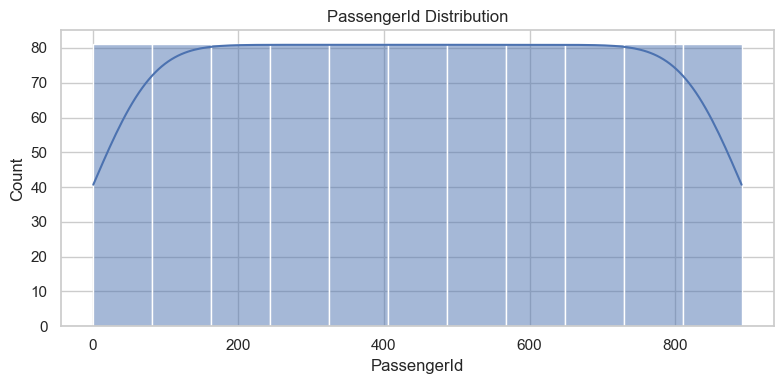

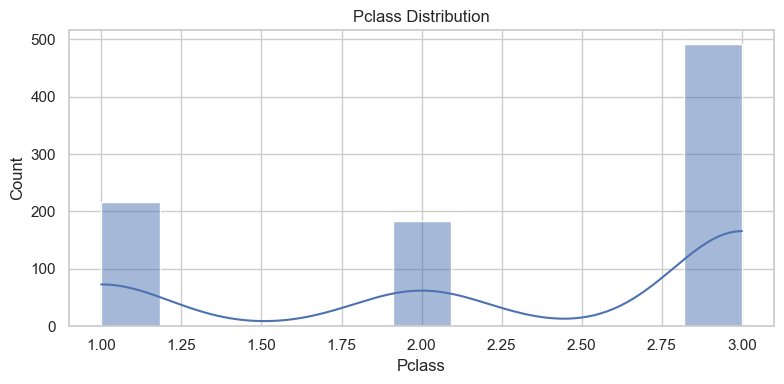

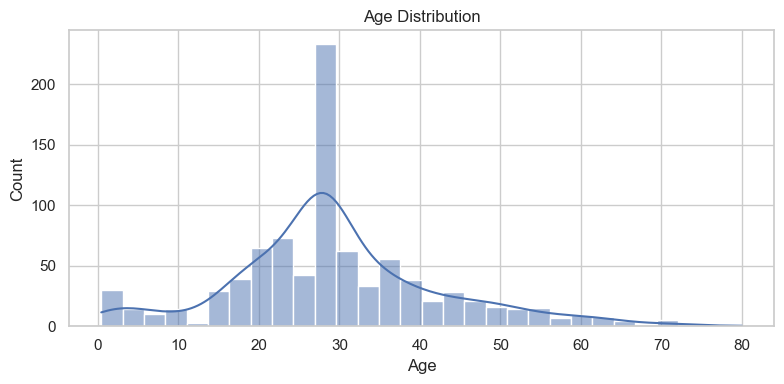

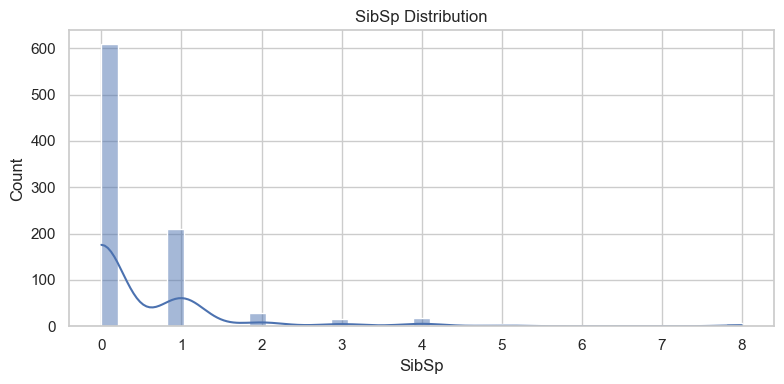

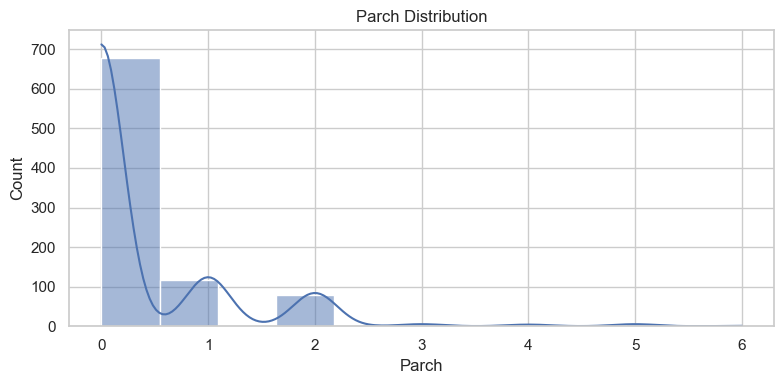

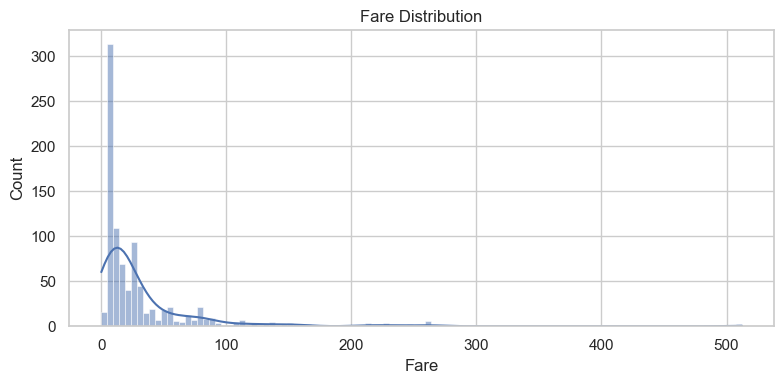

In [5]:
# ============================================================
# 4. 숫자형 변수 분포 확인 및 저장
# ============================================================

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(train[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.savefig(f"../../output/figures/univariate_{col.lower()}_distribution.png",bbox_inches='tight')
    plt.show()

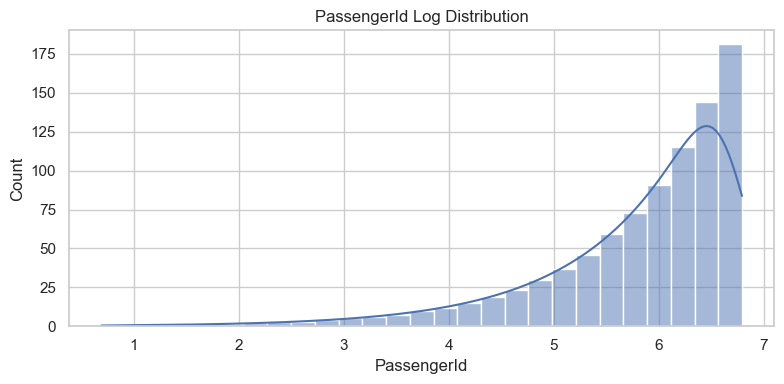

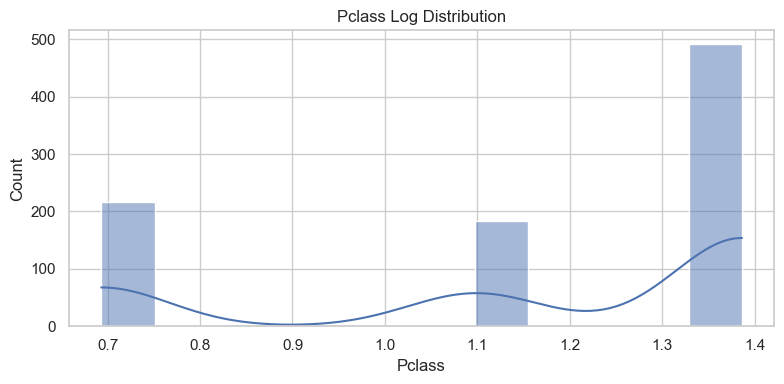

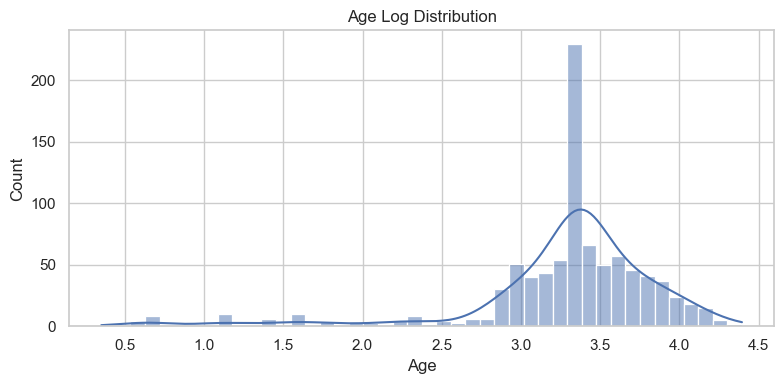

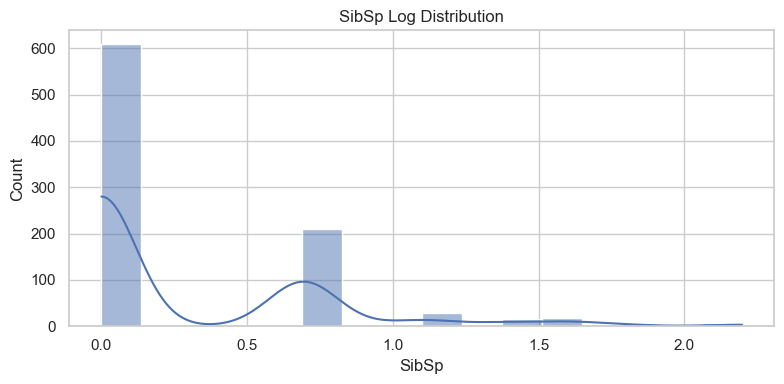

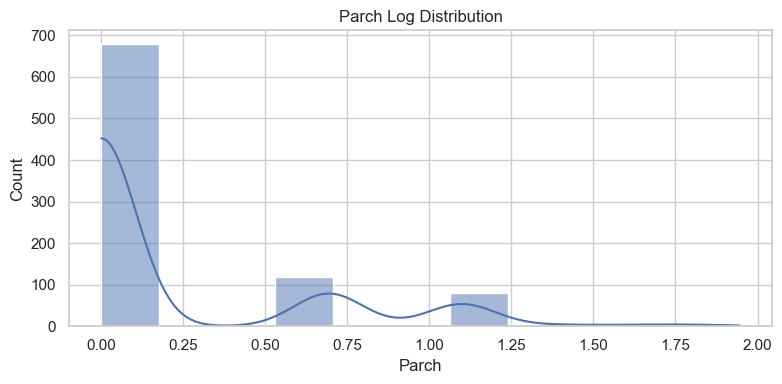

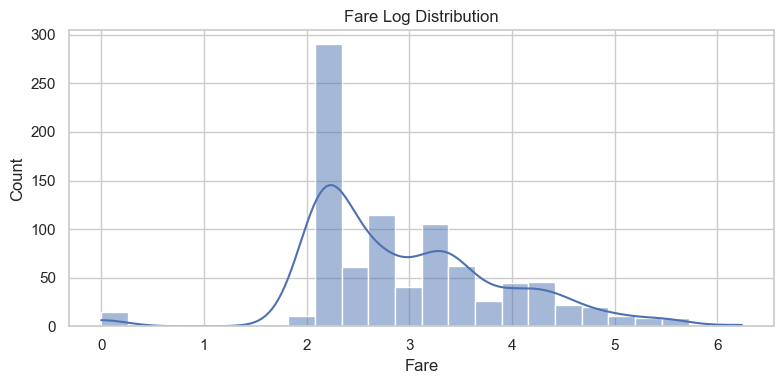

In [6]:
# ============================================================
# 숫자형 변수 로그 분포 확인 및 저장
# ============================================================

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(np.log1p(train[col]),kde=True)
    plt.title(f"{col} Log Distribution")
    plt.tight_layout()
    plt.savefig(f"../../output/figures/univariate_{col.lower()}_log_distribution.png", bbox_inches='tight')
    plt.show()

분포 그래프에서 skew를 확인하고, 로그 변환 후 분포가 개선되면 모델 입력 변수로 로그 변환을 고려하고, 개선이 없으면 적용하지 않습니다.

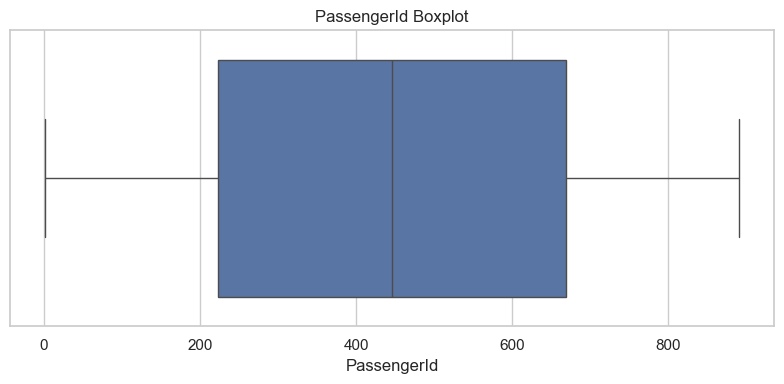

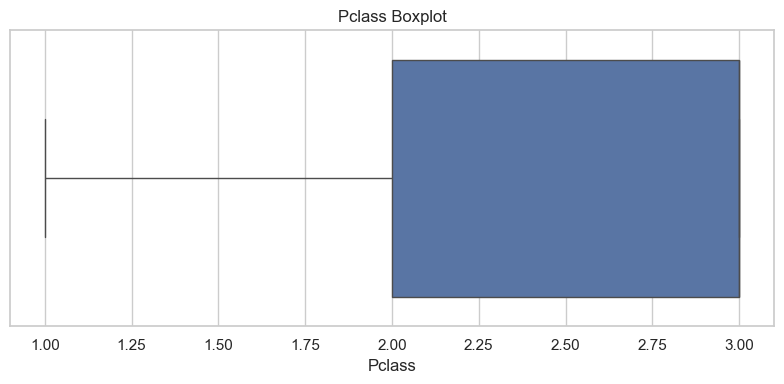

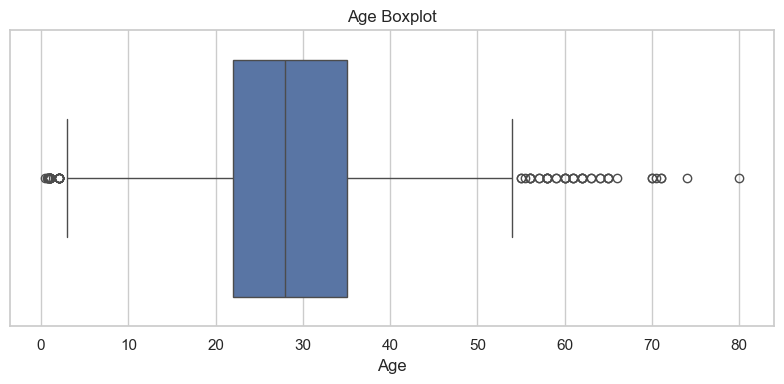

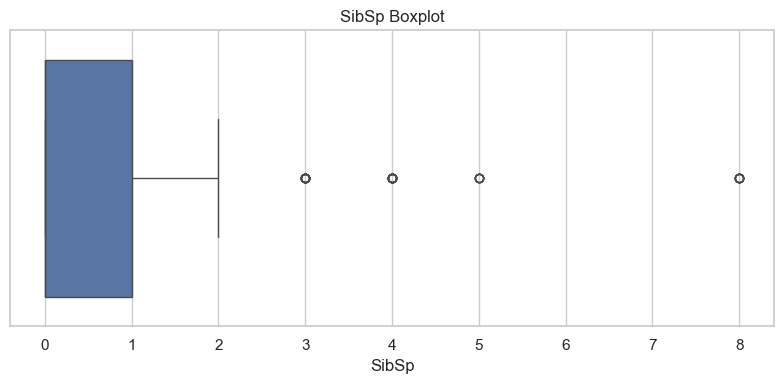

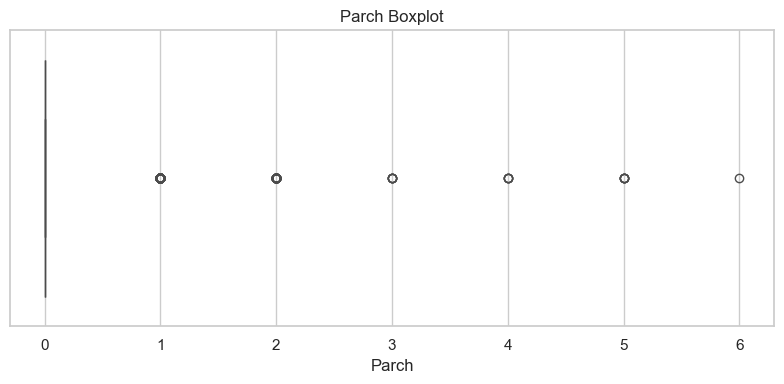

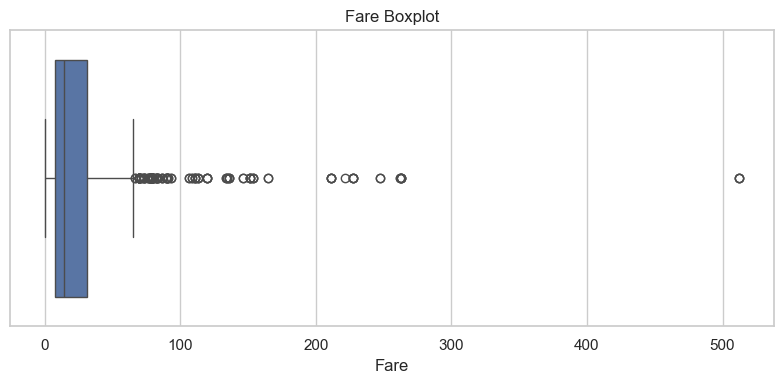

In [7]:
# ============================================================
# 6. 숫자형 변수 박스플롯 확인 및 저장
# ============================================================

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=train[col])
    plt.title(f"{col} Boxplot")
    plt.tight_layout()
    plt.savefig(f"../../output/figures/univariate_{col.lower()}_boxplot.png", bbox_inches='tight')
    plt.show()

In [8]:
# ============================================================
# 7. 숫자형 변수 왜도 확인
# ============================================================

print("\n[왜도 확인]")
for col in num_cols:
    print(f"{col} : {train[col].skew():.2f}")


[왜도 확인]
PassengerId : 0.00
Pclass : -0.63
Age : 0.49
SibSp : 3.70
Parch : 2.75
Fare : 4.79


| 값       | 해석               |
| ------- | ---------------- |
| 0에 가까움  | 대칭 (정규분포 느낌)     |
| 0.5 이하  | 거의 대칭            |
| 0.5 ~ 1 | 약간 치우침           |
| 1 이상    | 심하게 치우침 (skewed) |

양수(+) → 오른쪽 꼬리

음수(-) → 왼쪽 꼬리

| 변수          | 판단           |
| ----------- | ------------ |
| PassengerId | 식별자라 제거           |
| Pclass      | 범주형이라 신경 X   |
| Age         | 그대로 사용       |
| SibSp       | 변환 고려        |
| Parch       | 변환 고려        |
| Fare        | 무조건 로그 고려 |


In [11]:
# ============================================================
# 8. 범주형 변수 빈도 확인
# ============================================================

max_categories_for_plot = 10
top_n = 10

for col in obj_cols:
    nunique_count = train[col].nunique(dropna=False)

    print(f"\n==== {col} ====")
    print(f"고유값 개수: {nunique_count}")

    if nunique_count <= max_categories_for_plot:
        print("\n[빈도]")
        print(train[col].value_counts(dropna=False))

        print("\n[비율 (%)]")
        print((train[col].value_counts(dropna=False, normalize=True) * 100).round(2))
    else:
        print(f"[주의] 고유값이 많아 상위 {top_n}개만 출력")
        print(train[col].value_counts(dropna=False).head(top_n))
        print((train[col].value_counts(dropna=False, normalize=True).head(top_n) * 100).round(2))


==== Name ====
고유값 개수: 891
[주의] 고유값이 많아 상위 10개만 출력
Name
Braund, Mr. Owen Harris                            1
Boulos, Mr. Hanna                                  1
Frolicher-Stehli, Mr. Maxmillian                   1
Gilinski, Mr. Eliezer                              1
Murdlin, Mr. Joseph                                1
Rintamaki, Mr. Matti                               1
Stephenson, Mrs. Walter Bertram (Martha Eustis)    1
Elsbury, Mr. William James                         1
Bourke, Miss. Mary                                 1
Chapman, Mr. John Henry                            1
Name: count, dtype: int64
Name
Braund, Mr. Owen Harris                           0.11
Boulos, Mr. Hanna                                 0.11
Frolicher-Stehli, Mr. Maxmillian                  0.11
Gilinski, Mr. Eliezer                             0.11
Murdlin, Mr. Joseph                               0.11
Rintamaki, Mr. Matti                              0.11
Stephenson, Mrs. Walter Bertram (Martha Eustis)   0.

[그래프 생략] Name (고유값 891 개)


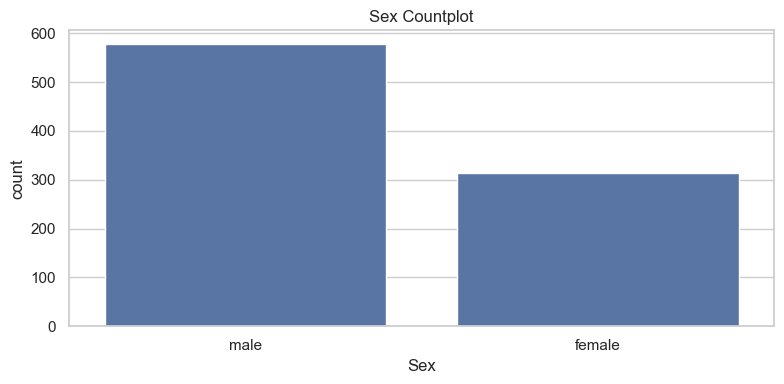

[그래프 생략] Ticket (고유값 681 개)
[그래프 생략] Cabin (고유값 148 개)


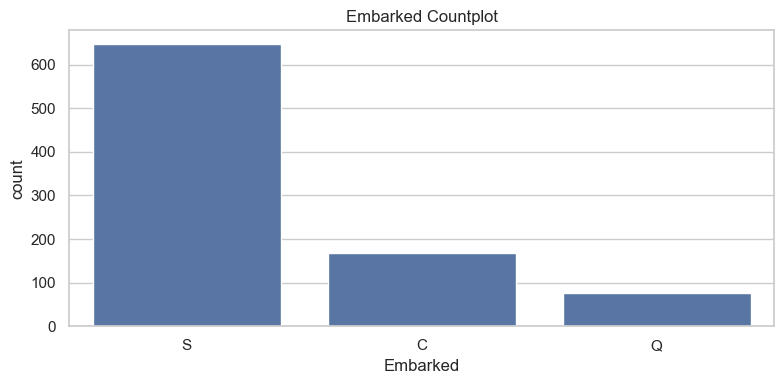

In [14]:
# ============================================================
# 9. 범주형 변수 countplot 확인 및 저장
# ============================================================
for col in obj_cols:
    nunique_count = train[col].nunique(dropna=False)

    if nunique_count <= max_categories_for_plot:
        plt.figure(figsize=(8,4))
        sns.countplot(data=train, 
                      x=col, 
                      order=train[col].value_counts(dropna=False).index)
        plt.title(f"{col} Countplot")
        plt.tight_layout()
        plt.savefig(f"../../output/figures/univariate_{col.lower()}_countplot.png", bbox_inches='tight')
        plt.show()
    else:
        print(f"[그래프 생략] {col} (고유값 {nunique_count} 개)")

In [19]:
# ============================================================
# 10. 단변량 요약표 생성
# ============================================================

univariate_summary = pd.DataFrame({
    'dtype' : train.dtypes.astype(str),
    'nunique' : train.nunique(dropna=False),
    'missing_count' : train.isnull().sum(),
    'missing_ratio' : (train.isnull().sum() / len(train)) * 100,
    'mean' : train.mean(numeric_only=True),
    'median': train.median(numeric_only=True),
    'std' : train.std(numeric_only=True),
    'min' : train.min(numeric_only=True),
    'q1' : train.quantile(0.25, numeric_only=True),
    'q3' : train.quantile(0.75, numeric_only=True),
    'max':train.max(numeric_only=True),
    'skew':train.skew(numeric_only=True),
    'kurtosis': train.kurtosis(numeric_only=True)
})

In [21]:
# ============================================================
# 11. 요약표 확인 및 저장
print("\n[단변량 요약표]")
display(univariate_summary)

univariate_summary.to_csv("../../output/tables/univariate_summary.csv", index=True)

print("\nunivariate_summary.csv 저장 완료")


[단변량 요약표]


,dtype,nunique,missing_count,missing_ratio,mean,median,std,min,q1,q3,max,skew,kurtosis
Age,float64,88,0,0.00,29.43,28.00,13.03,0.42,22.00,35.00,80.00,0.49,0.97
Cabin,object,148,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Embarked,object,3,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,float64,248,0,0.00,32.20,14.45,49.69,0.00,7.91,31.00,512.33,4.79,33.40
Name,object,891,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parch,int64,7,0,0.00,0.38,0.00,0.81,0.00,0.00,0.00,6.00,2.75,9.78
PassengerId,int64,891,0,0.00,446.00,446.00,257.35,1.00,223.50,668.50,891.00,0.00,-1.20
Pclass,int64,3,0,0.00,2.31,3.00,0.84,1.00,2.00,3.00,3.00,-0.63,-1.28
Sex,object,2,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,int64,7,0,0.00,0.52,0.00,1.10,0.00,0.00,1.00,8.00,3.70,17.88



univariate_summary.csv 저장 완료
